# SFSumoEnv — Model Evaluation

This notebook loads a trained DQN agent (speedFactor) and evaluates it on traffic data.

## Instructions
1. Place your trained `dqn_best.pt` in `models/sf/`
2. Place your evaluation CSV in `data/sf/eval_data.csv` (format: CCTV Data Remastered.csv \u2014 13 semicolon-separated columns, first column is label)
3. Adjust config variables below if needed
4. Run all cells

In [1]:
import os
import sys
import csv
import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

_proj_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
for p in [_proj_root, os.path.join(_proj_root, "src")]:
    if p not in sys.path:
        sys.path.insert(0, p)
if "SUMO_HOME" in os.environ:
    sys.path.append(os.path.join(os.environ["SUMO_HOME"], "tools"))

from src.data_repo import DataRepo
from src.agents.dqn_agent import DQNAgent

%matplotlib inline

In [2]:
from src.envs.sf_env import SFSumoEnv

MODEL_PATH = Path("models/sf/dqn_best.pt")
DATA_PATH = Path("data/sf/eval_data.csv")
SUMO_BINARY = "sumo"
WARMUP_MINUTES = 5
PERIOD_MINUTES = 10
STEP_LENGTH = 1.0
MAX_ROWS = 28  # set to int to limit rows for quick testing
SAVE_RESULTS = True
USE_HOURLY = True  # True=columns 7-12 (\x6), False=columns 1-6 (10-min)

STATE_DIM = 7
ACTION_DIM = 5
ENV_CLASS = SFSumoEnv

print("Configuration:")
print(f"  Model: {MODEL_PATH}")
print(f"  Data:  {DATA_PATH}")
print(f"  Env:   SFSumoEnv (state_dim={STATE_DIM}, action_dim={ACTION_DIM})")
print(f"  step_length={STEP_LENGTH}, warmup={WARMUP_MINUTES}min, period={PERIOD_MINUTES}min")
print(f"  MAX_ROWS={'unlimited' if MAX_ROWS is None else MAX_ROWS}")

Configuration:
  Model: models\sf\dqn_best.pt
  Data:  data\sf\eval_data.csv
  Env:   SFSumoEnv (state_dim=7, action_dim=5)
  step_length=1.0, warmup=5min, period=10min
  MAX_ROWS=28


In [3]:
def load_eval_data(csv_path, max_rows=None, hourly=True):
    df = pd.read_csv(csv_path, sep=";", header=0)
    cols = list(range(7, 13)) if hourly else list(range(1, 7))
    data = df.iloc[:, cols].values.astype(np.float32)
    mask = (data[:, 4] != 0) & (data[:, 5] != 0)
    data = data[mask]
    if max_rows is not None:
        data = data[:max_rows]
    print(f"Loaded {len(data)} data point(s) from {csv_path} ({"hourly" if hourly else "10-min"})")
    for i, row in enumerate(data):
        print(f"  [{i}] SL={row[0]:.0f}  SPT={row[1]:.0f}  UL={row[2]:.0f}  UPT={row[3]:.0f}  "
              f"OS={row[4]:.0f}  OU={row[5]:.0f}")
    return data

data = load_eval_data(DATA_PATH, MAX_ROWS, USE_HOURLY)

Loaded 28 data point(s) from data\sf\eval_data.csv (hourly)
  [0] SL=390  SPT=204  UL=384  UPT=36  OS=588  OU=426
  [1] SL=780  SPT=342  UL=960  UPT=60  OS=1302  OU=840
  [2] SL=684  SPT=336  UL=1032  UPT=36  OS=1368  OU=720
  [3] SL=762  SPT=210  UL=480  UPT=48  OS=690  OU=810
  [4] SL=756  SPT=276  UL=1086  UPT=114  OS=1362  OU=870
  [5] SL=924  SPT=492  UL=1302  UPT=84  OS=1794  OU=1008
  [6] SL=732  SPT=462  UL=1026  UPT=90  OS=1488  OU=822
  [7] SL=684  SPT=186  UL=666  UPT=36  OS=852  OU=720
  [8] SL=630  SPT=282  UL=1128  UPT=132  OS=1410  OU=762
  [9] SL=606  SPT=330  UL=858  UPT=48  OS=1188  OU=654
  [10] SL=720  SPT=384  UL=876  UPT=48  OS=1260  OU=768
  [11] SL=594  SPT=180  UL=564  UPT=48  OS=744  OU=642
  [12] SL=504  SPT=168  UL=540  UPT=90  OS=708  OU=594
  [13] SL=816  SPT=282  UL=1050  UPT=102  OS=1332  OU=918
  [14] SL=870  SPT=324  UL=678  UPT=54  OS=1002  OU=924
  [15] SL=606  SPT=204  UL=636  UPT=24  OS=840  OU=630
  [16] SL=552  SPT=186  UL=996  UPT=84  OS=1182  O

In [4]:
repo = DataRepo()
env = ENV_CLASS(
    sumo_config_path=str(repo.sumo_config_path),
    sumo_binary=SUMO_BINARY,
    step_length=STEP_LENGTH,
    warmup_minutes=WARMUP_MINUTES,
    period_minutes=PERIOD_MINUTES,
    reward_scale=1.0,
    reset_params_on_reset=True,
)
env.set_target_data(data)
flow_max = float(np.max(data[:, :4]))
print(f"flow_max = {flow_max:.1f}  (used for state normalization)")

flow_max = 1302.0  (used for state normalization)


In [5]:
agent = DQNAgent(state_dim=STATE_DIM, action_dim=ACTION_DIM)
agent.load(str(MODEL_PATH))
agent.q_net.eval()
agent.target_net.eval()
print(f"Model loaded from {MODEL_PATH.resolve()}")
print(f"Device: {agent.device}")

Model loaded from E:\Kuliah\Skripsi\Project\SUMO-dinamic-tuning-AI\jupyter\models\sf\dqn_best.pt
Device: cpu


In [6]:
results = []
n_data = len(data)
param_names = list(env.action_map[0].keys())
steps = 10

print(f"Running evaluation on {n_data} data point(s)...")
#print(f"(4 steps per data point, epsilon=0 greedy policy)\n")

for data_idx in range(n_data):
    obs, _ = env.reset()
    row_steps = []
    for step in range(steps):
        action = agent.act(obs, epsilon=0.0)
        next_obs, reward, terminated, _, info = env.step(action)
        entry = {"step": step + 1, "action": int(action)}
        entry.update(info["params"])
        entry.update({
            "sim_north": info["sim_north"],
            "sim_south": info["sim_south"],
            "expected_north": info["expected_north"],
            "expected_south": info["expected_south"],
            "reward": float(reward),
        })
        row_steps.append(entry)
        obs = next_obs

    first_mape = -row_steps[0]["reward"]
    last_mape = -row_steps[-1]["reward"]
    flow_str = (f"SL={data[data_idx][0]:.0f} SPT={data[data_idx][1]:.0f} "
                f"UL={data[data_idx][2]:.0f} UPT={data[data_idx][3]:.0f}")
    print(f"  [{data_idx+1:2d}/{n_data}] {flow_str}  "
          f"MAPE: {first_mape:.3f} \u2192 {last_mape:.3f}  "
          f"({param_names[0]}={row_steps[-1][param_names[0]]:.2f})")

    results.append({
        "data_idx": data_idx,
        "sl": float(data[data_idx][0]),
        "spt": float(data[data_idx][1]),
        "ul": float(data[data_idx][2]),
        "upt": float(data[data_idx][3]),
        "os": float(data[data_idx][4]),
        "ou": float(data[data_idx][5]),
        "steps": row_steps,
    })

print(f"\nDone — {n_data} data point(s) evaluated.")
# Baseline measurement (SUMO defaults)
baseline_map = {}
for data_idx in range(n_data):
    env.current_data_idx = data_idx
    obs, _ = env.reset()
    rew, info = env.measure_baseline()
    baseline_map[data_idx] = -rew
    print(f"  [{data_idx+1:2d}/{n_data}] baseline_mape={-rew:.4f}")

for r in results:
    r["baseline_mape"] = baseline_map[r["data_idx"]]
    dqn_mape = -r["steps"][-1]["reward"]
    r["improvement"] = r["baseline_mape"] - dqn_mape

print(f"Baseline complete. improvement computed for all {n_data} data point(s).")

Running evaluation on 28 data point(s)...
  [ 1/28] SL=390 SPT=204 UL=384 UPT=36  MAPE: 0.042 → 0.022  (speedFactor=1.09)
  [ 2/28] SL=780 SPT=342 UL=960 UPT=60  MAPE: 0.053 → 0.064  (speedFactor=0.67)
  [ 3/28] SL=684 SPT=336 UL=1032 UPT=36  MAPE: 0.116 → 0.107  (speedFactor=0.73)
  [ 4/28] SL=762 SPT=210 UL=480 UPT=48  MAPE: 0.241 → 0.204  (speedFactor=0.71)
  [ 5/28] SL=756 SPT=276 UL=1086 UPT=114  MAPE: 0.042 → 0.022  (speedFactor=1.09)
  [ 6/28] SL=924 SPT=492 UL=1302 UPT=84  MAPE: 0.053 → 0.064  (speedFactor=0.67)
  [ 7/28] SL=732 SPT=462 UL=1026 UPT=90  MAPE: 0.116 → 0.107  (speedFactor=0.73)
  [ 8/28] SL=684 SPT=186 UL=666 UPT=36  MAPE: 0.241 → 0.204  (speedFactor=0.71)
  [ 9/28] SL=630 SPT=282 UL=1128 UPT=132  MAPE: 0.042 → 0.022  (speedFactor=1.09)
  [10/28] SL=606 SPT=330 UL=858 UPT=48  MAPE: 0.053 → 0.064  (speedFactor=0.67)
  [11/28] SL=720 SPT=384 UL=876 UPT=48  MAPE: 0.116 → 0.107  (speedFactor=0.73)
  [12/28] SL=594 SPT=180 UL=564 UPT=48  MAPE: 0.241 → 0.204  (speedFact

In [7]:
rows_summary = []
for r in results:
    first = r["steps"][0]
    last = r["steps"][-1]
    mape_start = -first["reward"]
    mape_end = -last["reward"]
    rows_summary.append({
        "DataIdx": r["data_idx"],
        "SL": r["sl"], "SPT": r["spt"], "UL": r["ul"], "UPT": r["upt"],
        "OS": r["os"], "OU": r["ou"],
        f"{param_names[0]}_start": first[param_names[0]],
        f"{param_names[0]}_end": last[param_names[0]],
        "SimN_start": first["sim_north"], "SimS_start": first["sim_south"],
        "SimN_end": last["sim_north"], "SimS_end": last["sim_south"],
        "ExpN": first["expected_north"], "ExpS": first["expected_south"],
        "MAPE_start": round(mape_start, 4),
        "MAPE_end": round(mape_end, 4),
        "Improvement": round(mape_start - mape_end, 4),
        "Baseline": round(r["baseline_mape"], 4),
        "Improvement": round(r["improvement"], 4),
    })

df_summary = pd.DataFrame(rows_summary)
print("Per-Data-Point Summary:")
display(df_summary)

print("\nAggregate Metrics:")
avg_start = df_summary["MAPE_start"].mean()
avg_end = df_summary["MAPE_end"].mean()
print(f"  Mean MAPE (step 1): {avg_start:.4f}")
print(f"  Mean MAPE (last step): {avg_end:.4f}")
print(f"  Mean improvement:   {(avg_start - avg_end):+.4f}")
print(f"  Rows improved:      {(df_summary['Improvement'] > 0).sum()} / {len(df_summary)}")
print(f"  Rows worsened:      {(df_summary['Improvement'] < 0).sum()} / {len(df_summary)}")
avg_delta = df_summary["Improvement"].mean()
print(f"  Mean improvement:  {avg_delta:+.4f}")
print(f"  DQN beat baseline: {(df_summary['Improvement'] < 0).sum()} / {len(df_summary)}")
print(f"  DQN worse than baseline:    {(df_summary['Improvement'] > 0).sum()} / {len(df_summary)}")

Per-Data-Point Summary:


,DataIdx,SL,SPT,UL,UPT,OS,OU,speedFactor_start,speedFactor_end,SimN_start,SimS_start,SimN_end,SimS_end,ExpN,ExpS,MAPE_start,MAPE_end,Improvement,Baseline
0,0,390.0,204.0,384.0,36.0,588.0,426.0,0.99,1.09,68,94,70,95,71.0,98.0,0.0415,0.0223,0.0141,0.0364
1,1,780.0,342.0,960.0,60.0,1302.0,840.0,0.90,0.67,115,133,113,132,120.0,142.0,0.0525,0.0644,0.2126,0.2770
2,2,684.0,336.0,1032.0,36.0,1368.0,720.0,0.90,0.73,146,137,145,141,154.0,167.0,0.1158,0.1071,0.1443,0.2513
3,3,762.0,210.0,480.0,48.0,690.0,810.0,0.90,0.71,81,152,89,152,109.0,196.0,0.2407,0.2040,-0.1072,0.0968
4,4,756.0,276.0,1086.0,114.0,1362.0,870.0,0.99,1.09,68,94,70,95,71.0,98.0,0.0415,0.0223,0.1200,0.1423
5,5,924.0,492.0,1302.0,84.0,1794.0,1008.0,0.90,0.67,115,133,113,132,120.0,142.0,0.0525,0.0644,0.3662,0.4306
6,6,732.0,462.0,1026.0,90.0,1488.0,822.0,0.90,0.73,146,137,145,141,154.0,167.0,0.1158,0.1071,0.2514,0.3585
7,7,684.0,186.0,666.0,36.0,852.0,720.0,0.90,0.71,81,152,89,152,109.0,196.0,0.2407,0.2040,-0.1374,0.0666
8,8,630.0,282.0,1128.0,132.0,1410.0,762.0,0.99,1.09,68,94,70,95,71.0,98.0,0.0415,0.0223,0.1570,0.1794
9,9,606.0,330.0,858.0,48.0,1188.0,654.0,0.90,0.67,115,133,113,132,120.0,142.0,0.0525,0.0644,0.1970,0.2614



Aggregate Metrics:
  Mean MAPE (step 1): 0.1126
  Mean MAPE (last step): 0.0995
  Mean improvement:   +0.0132
  Rows improved:      22 / 28
  Rows worsened:      6 / 28
  Mean improvement:  +0.0976
  DQN beat baseline: 6 / 28
  DQN worse than baseline:    22 / 28


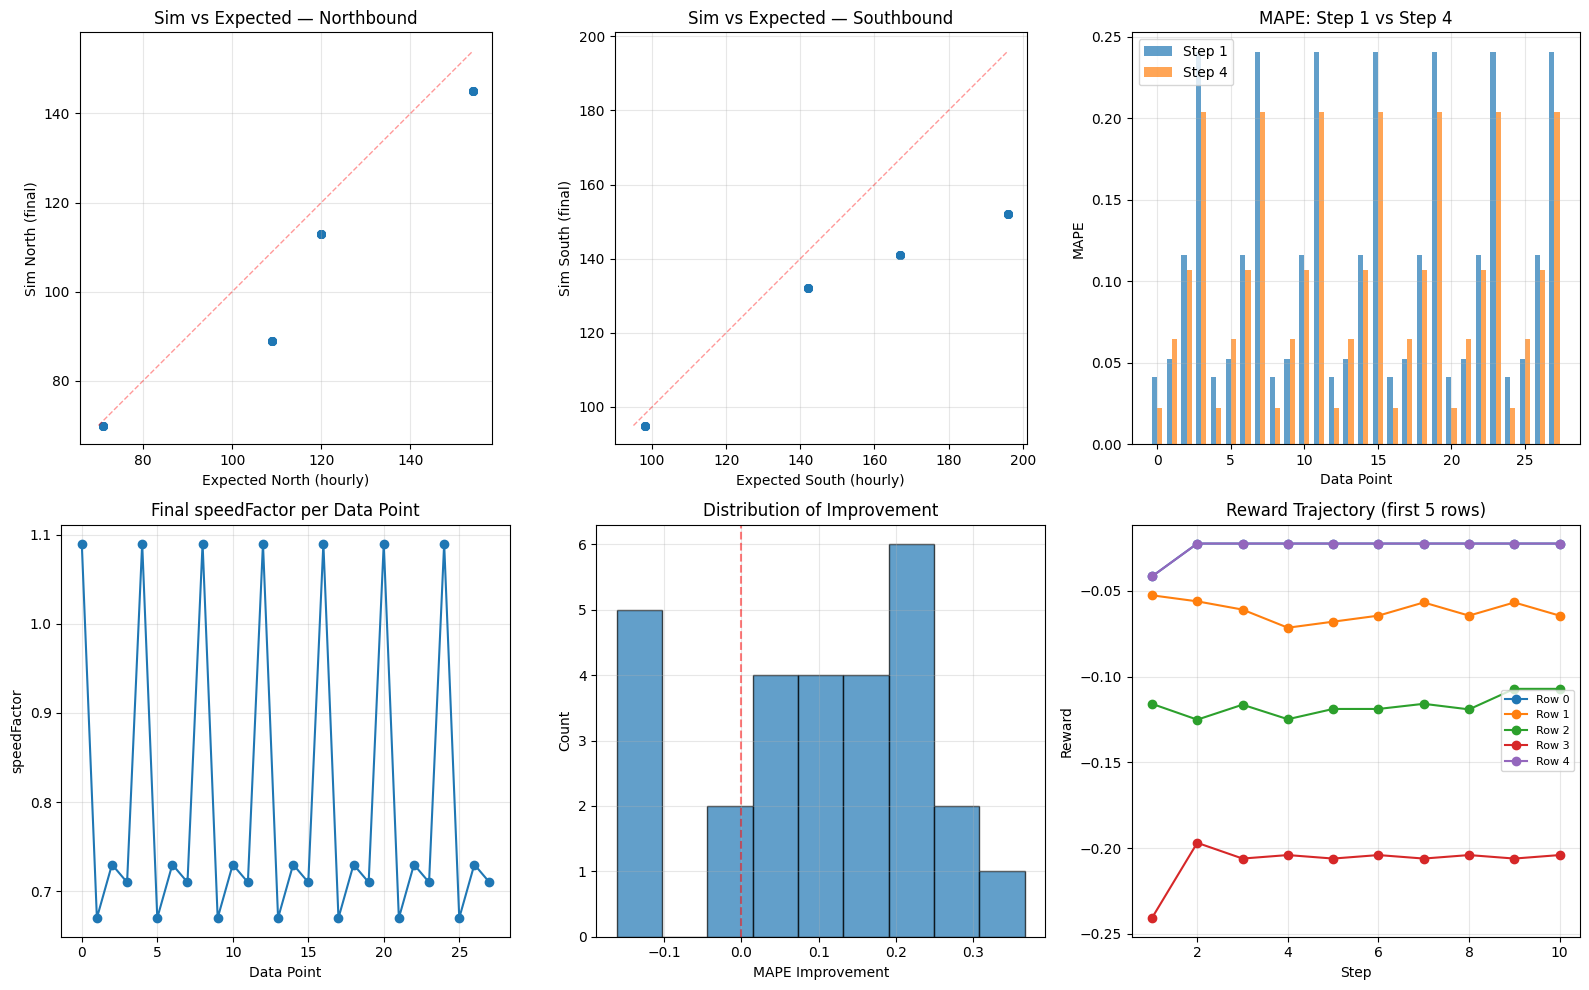

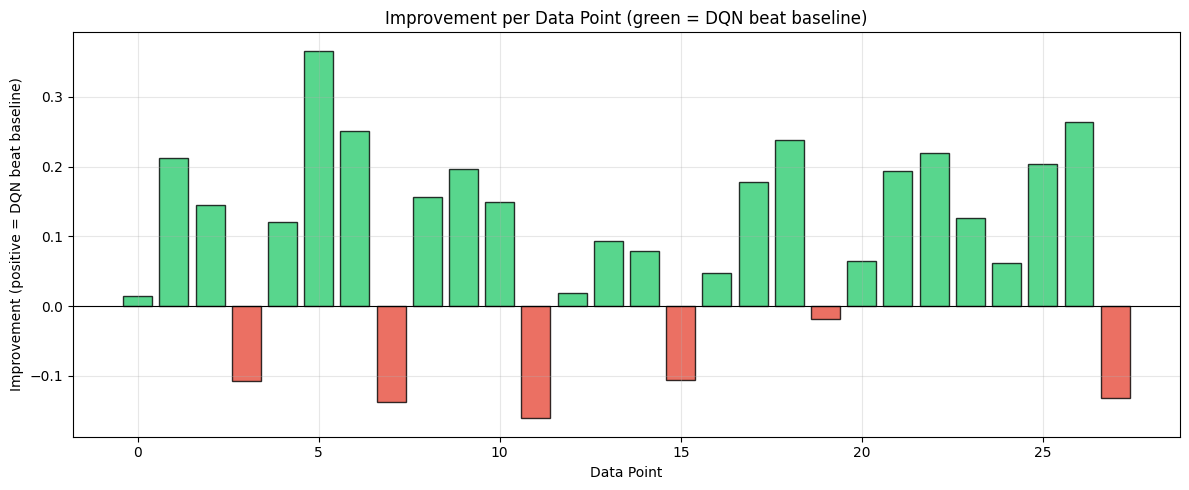

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# 1 — Sim vs Expected North
ax = axes[0, 0]
ax.scatter(df_summary["ExpN"], df_summary["SimN_end"], alpha=0.7, s=30)
lo = min(df_summary["ExpN"].min(), df_summary["SimN_end"].min())
hi = max(df_summary["ExpN"].max(), df_summary["SimN_end"].max())
ax.plot([lo, hi], [lo, hi], "r--", alpha=0.4, linewidth=1)
ax.set_xlabel("Expected North (hourly)"); ax.set_ylabel("Sim North (final)")
ax.set_title("Sim vs Expected \u2014 Northbound"); ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

# 2 — Sim vs Expected South
ax = axes[0, 1]
ax.scatter(df_summary["ExpS"], df_summary["SimS_end"], alpha=0.7, s=30)
lo = min(df_summary["ExpS"].min(), df_summary["SimS_end"].min())
hi = max(df_summary["ExpS"].max(), df_summary["SimS_end"].max())
ax.plot([lo, hi], [lo, hi], "r--", alpha=0.4, linewidth=1)
ax.set_xlabel("Expected South (hourly)"); ax.set_ylabel("Sim South (final)")
ax.set_title("Sim vs Expected \u2014 Southbound"); ax.grid(True, alpha=0.3)
ax.set_aspect("equal")

# 3 — MAPE: Step 1 vs Step 4
ax = axes[0, 2]
x = range(len(df_summary))
width = 0.35
ax.bar([i - width/2 for i in x], df_summary["MAPE_start"], width, label="Step 1", alpha=0.7)
ax.bar([i + width/2 for i in x], df_summary["MAPE_end"], width, label="Step 4", alpha=0.7)
ax.set_xlabel("Data Point"); ax.set_ylabel("MAPE")
ax.set_title("MAPE: Step 1 vs Step 4"); ax.legend(); ax.grid(True, alpha=0.3)

# 4 — Final parameter per data point
ax = axes[1, 0]
ax.plot(x, df_summary[f"{param_names[0]}_end"], "o-", label=param_names[0])
ax.set_xlabel("Data Point"); ax.set_ylabel(param_names[0])
ax.set_title(f"Final {param_names[0]} per Data Point"); ax.grid(True, alpha=0.3)

# 5 — Improvement histogram
ax = axes[1, 1]
bins = max(5, min(20, len(df_summary) // 3))
ax.hist(df_summary["Improvement"], bins=bins, alpha=0.7, edgecolor="black")
ax.axvline(0, color="r", linestyle="--", alpha=0.5)
ax.set_xlabel("MAPE Improvement"); ax.set_ylabel("Count")
ax.set_title("Distribution of Improvement"); ax.grid(True, alpha=0.3)

# 6 — Reward trajectory (first 5 rows)
ax = axes[1, 2]
for r in results[:5]:
    rewards = [s["reward"] for s in r["steps"]]
    ax.plot(range(1, len(rewards)+1), rewards, "o-", label=f"Row {r['data_idx']}")
ax.set_xlabel("Step"); ax.set_ylabel("Reward")
ax.set_title("Reward Trajectory (first 5 rows)")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

plt.tight_layout()


# 7 — Improvement: DQN vs Baseline
fig2, ax2 = plt.subplots(figsize=(12, 5))
colors = ["#2ecc71" if d > 0 else "#e74c3c" for d in df_summary["Improvement"]]
ax2.bar(df_summary["DataIdx"], df_summary["Improvement"], color=colors, edgecolor="black", alpha=0.8)
ax2.axhline(0, color="black", linewidth=0.8)
ax2.set_xlabel("Data Point")
ax2.set_ylabel("Improvement (positive = DQN beat baseline)")
ax2.set_title("Improvement per Data Point (green = DQN beat baseline)")
ax2.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [9]:
if SAVE_RESULTS:
    rows_flat = []
    for r in results:
        for s in r["steps"]:
            row = {
                "data_idx": r["data_idx"],
                "sl": r["sl"], "spt": r["spt"], "ul": r["ul"], "upt": r["upt"],
                "os": r["os"], "ou": r["ou"],
                "step": s["step"], "action": s["action"],
            }
            row[param_names[0]] = s[param_names[0]]
            row.update({
                "sim_north": s["sim_north"], "sim_south": s["sim_south"],
                "expected_north": s["expected_north"], "expected_south": s["expected_south"],
                "reward": s["reward"],
            })
            rows_flat.append(row)
    df_flat = pd.DataFrame(rows_flat)
    ts = datetime.datetime.now().strftime("%Y%m%d_%H%M%S")
    out_dir = Path("data/sf")
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / f"eval_results_{ts}.csv"
    df_flat.to_csv(out_path, index=False)
    print(f"Results saved to {out_path}")
else:
    print("SAVE_RESULTS is False, skipping CSV export.")

Results saved to data\sf\eval_results_20260729_204323.csv


In [10]:
env.close()
print("SUMO processes cleaned up.")

SUMO processes cleaned up.
